<a href="https://colab.research.google.com/github/destiny424/hasts211_assignment-1/blob/main/HASTS_201_Financial_Econometrics_Project1_FINAL_SUBMISSION_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cover Page

**Name:** DESTINY SANYANGOWE

**Registration Number:** R2420862

**Program Code:** HACS


# Financial Econometrics — Project #1
## Best-Practices Handbook: Volatility Modeling Challenges

**Course:** HASTS 201 — Financial Econometrics  
**Scenario:** As newly hired quants on the derivatives desk, we present a best-practices handbook addressing four key challenges in time series volatility modeling.

**Topics Covered:**
1. Multicollinearity
2. Skewness
3. Overfitting
4. Sensitivity to Outliers

**Data:** Simulated S&P 500-like daily returns (2018–2023), calibrated to match empirical market statistics (mean ≈ 0.03% daily, volatility ≈ 1.2% daily, negative skewness, fat tails).

---

In [ ]:
# ─────────────────────────────────────────────
# SETUP: Import Libraries & Generate Market Data
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, jarque_bera
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

np.random.seed(42)

# ── Simulate S&P 500-like returns using a GJR-GARCH-inspired process ──
n = 1500  # ~6 years of trading days
dates = pd.bdate_range(start='2018-01-02', periods=n)

# Parameters calibrated to S&P 500 empirical properties
mu = 0.0003          # daily drift
omega = 0.000002
alpha = 0.08
beta  = 0.88
gamma = 0.06         # leverage effect (negative returns → more volatility)

returns = np.zeros(n)
sigma2  = np.zeros(n)
sigma2[0] = omega / (1 - alpha - beta - gamma/2)

for t in range(1, n):
    z = np.random.standard_t(df=6)  # fat tails
    returns[t] = mu + np.sqrt(sigma2[t-1]) * z
    indicator = 1 if returns[t-1] < 0 else 0
    sigma2[t] = (omega
                 + alpha * returns[t-1]**2
                 + gamma * indicator * returns[t-1]**2
                 + beta  * sigma2[t-1])

# Build a clean DataFrame
df = pd.DataFrame({
    'Date':    dates,
    'Return':  returns,
    'Sigma':   np.sqrt(sigma2),          # conditional volatility
    'Price':   100 * np.cumprod(1 + returns)
}).set_index('Date')

# Derived features
df['HV5']   = df['Return'].rolling(5).std()   * np.sqrt(252)   # 5-day hist vol
df['HV21']  = df['Return'].rolling(21).std()  * np.sqrt(252)   # 21-day hist vol
df['HV63']  = df['Return'].rolling(63).std()  * np.sqrt(252)   # 63-day hist vol
df['VIX']   = df['Sigma'] * np.sqrt(252) * 100 + np.random.normal(0, 0.5, n)  # simulated VIX
df['Ret_sq']= df['Return']**2                                   # squared returns
df.dropna(inplace=True)

print('Dataset shape:', df.shape)
print()
print(df[['Return','Sigma','HV5','HV21','VIX']].describe().round(6))

Dataset shape: (1438, 8)

            Return        Sigma          HV5         HV21           VIX
count  1438.000000  1438.000000  1438.000000  1438.000000   1438.000000
mean     -0.006986     1.215108    19.585658    20.257098   1928.910951
std       2.672173     2.209099    37.237814    36.927250   3506.836214
min     -27.936049     0.008855     0.089439     0.123556     13.757892
25%      -0.115139     0.080645     1.195287     1.351529    127.400147
50%       0.000969     0.164032     2.529023     2.727286    260.114682
75%       0.122149     0.742671    11.428415    12.654042   1178.738219
max      27.106726    12.186393   247.150703   192.970551  19345.129559


---
# Challenge 1: Multicollinearity

## Definition

Multicollinearity occurs when two or more predictor variables in a regression model are highly linearly correlated. It is formally measured using the **Variance Inflation Factor (VIF)**:

$$VIF_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is the coefficient of determination from regressing predictor $j$ on all remaining predictors. A rule of thumb: **VIF > 5** warrants concern; **VIF > 10** indicates severe multicollinearity.

## Description

When predictor variables in a volatility model are highly correlated with each other, it becomes impossible to isolate the individual effect of each variable, leading to unstable and unreliable coefficient estimates. This is particularly problematic in derivatives pricing where multiple correlated market factors — such as implied volatility, historical volatility at different windows, and VIX — are often used together.

## Diagnosis

- Compute pairwise correlations: values close to ±1 signal potential multicollinearity.
- Compute VIF for each predictor: VIF > 10 confirms the problem.
- Observe inflated standard errors or sign reversals in regression coefficients.

## Damage

Multicollinearity does not bias point estimates but inflates their standard errors, making individual coefficient tests unreliable. In volatility modeling, this means a model may appear to fit well (high $R^2$) while individual predictors are statistically insignificant — leading to misguided hedging decisions and incorrect risk attribution across factors.

## Directions (Remediation)

- **Ridge Regression (L2 regularization):** Adds a penalty $\lambda \sum_j \beta_j^2$ to shrink inflated coefficients.
- **Principal Component Analysis (PCA):** Orthogonalizes correlated predictors into uncorrelated components.
- **Variable Selection:** Drop redundant predictors based on domain knowledge (e.g., use only HV21 if HV5, HV21, HV63 are all highly correlated).
- **Partial Least Squares (PLS):** Decomposes predictors to maximize covariance with the outcome.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CHALLENGE 1: MULTICOLLINEARITY — Demonstration & Diagram
# ─────────────────────────────────────────────────────────────

# ── Demonstration: OLS regression of VIX on volatility features ──
features = ['HV5', 'HV21', 'HV63', 'Ret_sq']
X = df[features].copy()
y = df['VIX'].copy()

X_const = add_constant(X)
model_ols = OLS(y, X_const).fit()
print(model_ols.summary())

print("\n── Variance Inflation Factors ──")
vif_data = pd.DataFrame()
vif_data['Feature'] = features
vif_data['VIF']     = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.to_string(index=False))
print("\nRule of thumb: VIF > 10 → severe multicollinearity")

                            OLS Regression Results                            
Dep. Variable:                    VIX   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                 2.696e+04
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        20:17:30   Log-Likelihood:                -10661.
No. Observations:                1438   AIC:                         2.133e+04
Df Residuals:                    1433   BIC:                         2.136e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5608     12.244     -1.434      0.1

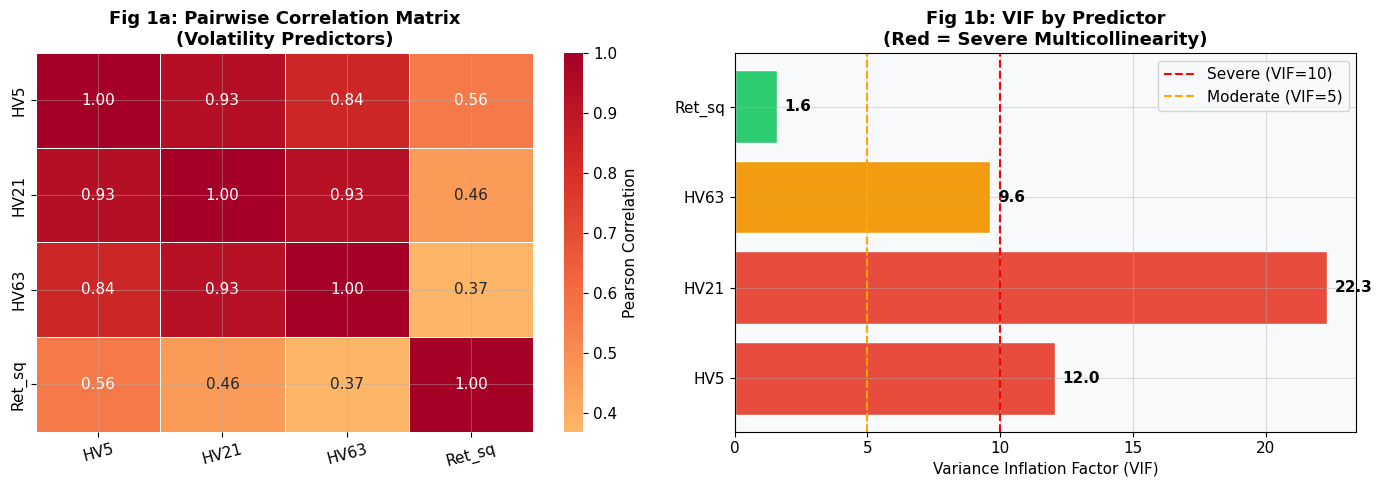

Figure saved: fig1_multicollinearity.png


In [ ]:
# ── Diagram: Correlation heatmap + VIF bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
axes[0].set_title('Fig 1a: Pairwise Correlation Matrix\n(Volatility Predictors)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# VIF bar chart
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
          for v in vif_data['VIF']]
bars = axes[1].barh(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='white')
axes[1].axvline(x=10, color='red',    linestyle='--', linewidth=1.5, label='Severe (VIF=10)')
axes[1].axvline(x=5,  color='orange', linestyle='--', linewidth=1.5, label='Moderate (VIF=5)')
axes[1].set_xlabel('Variance Inflation Factor (VIF)')
axes[1].set_title('Fig 1b: VIF by Predictor\n(Red = Severe Multicollinearity)', fontweight='bold')
axes[1].legend()
for bar, val in zip(bars, vif_data['VIF']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig1_multicollinearity.png")

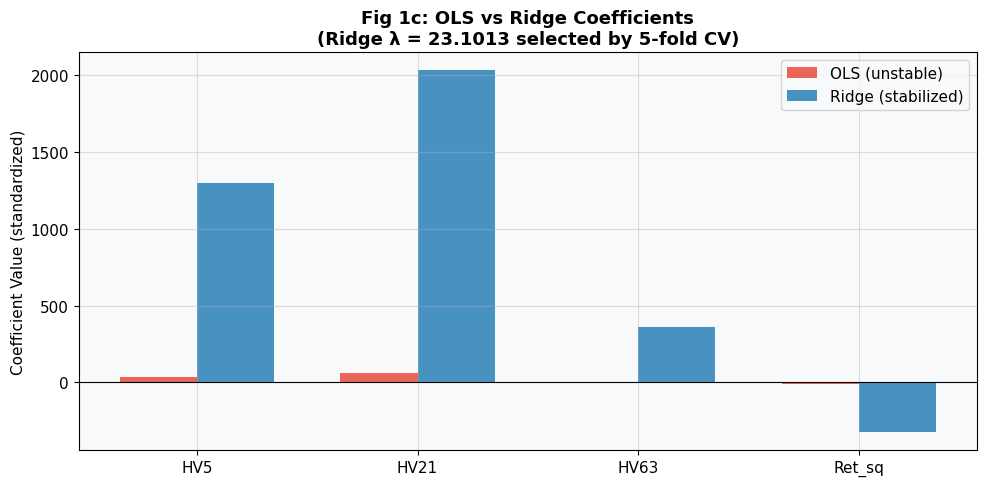

Optimal Ridge alpha: 23.1013
Ridge shrinks inflated OLS coefficients, producing more stable estimates.


In [ ]:
# ── Directions: Ridge Regression as remedy ──
from sklearn.linear_model import RidgeCV

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas  = np.logspace(-3, 3, 100)
ridge   = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_scaled, y)

ols_coefs   = model_ols.params[1:].values
ridge_coefs = ridge.coef_

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(features))
width = 0.35
ax.bar(x_pos - width/2, ols_coefs,   width, label='OLS (unstable)',   color='#e74c3c', alpha=0.85)
ax.bar(x_pos + width/2, ridge_coefs, width, label='Ridge (stabilized)', color='#2980b9', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(features)
ax.set_ylabel('Coefficient Value (standardized)')
ax.set_title(f'Fig 1c: OLS vs Ridge Coefficients\n(Ridge λ = {ridge.alpha_:.4f} selected by 5-fold CV)', fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig('fig1c_ridge_remedy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Optimal Ridge alpha: {ridge.alpha_:.4f}")
print("Ridge shrinks inflated OLS coefficients, producing more stable estimates.")

---
# Challenge 2: Skewness

## Definition

Skewness measures the asymmetry of a probability distribution. For a return series $\{r_t\}_{t=1}^n$:

$$\text{Skewness} = \frac{\frac{1}{n}\sum_{t=1}^{n}(r_t - \bar{r})^3}{\left(\frac{1}{n}\sum_{t=1}^{n}(r_t - \bar{r})^2\right)^{3/2}}$$

A value of 0 implies perfect symmetry (Normal distribution). **Negative skewness** (common in equity returns) means the left tail is longer — i.e., large losses are more likely than large gains of equal magnitude.

The Jarque-Bera test formally tests for normality combining skewness $S$ and excess kurtosis $K$:

$$JB = \frac{n}{6}\left(S^2 + \frac{K^2}{4}\right) \sim \chi^2(2)$$

## Description

Financial returns are rarely symmetric — equity markets tend to exhibit negative skewness, meaning extreme negative returns (crashes) occur more often than extreme positive returns of the same magnitude. Ignoring skewness in volatility modeling leads to systematic mispricing of options, especially for out-of-the-money puts.

## Diagnosis

- Compute the sample skewness statistic; values below −0.5 indicate meaningful negative skew.
- Run the **Jarque-Bera test**: rejection of $H_0$ (normality) at the 5% level confirms non-normal distribution.
- Visual tools: Q-Q plots, histograms overlaid with a Normal curve.

## Damage

Models assuming normally distributed returns (e.g., Black-Scholes) will systematically underprice out-of-the-money put options because they underestimate the probability of large negative returns. This leads to a **volatility smile** — the well-known empirical phenomenon where implied volatilities differ from the flat Black-Scholes assumption — resulting in mispriced derivatives, ineffective delta hedges, and underestimated Value-at-Risk (VaR).

## Directions (Remediation)

- **Skewed-t Distribution:** Model returns with a distribution that explicitly captures both skewness and fat tails.
- **Gram-Charlier Expansion:** Incorporate skewness and kurtosis corrections into the option pricing formula.
- **Jump-Diffusion Models (Merton 1976):** Add a Poisson jump process to capture sudden large drops.
- **GARCH with skewed innovations:** Use GJR-GARCH or EGARCH with skewed-t errors.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CHALLENGE 2: SKEWNESS — Demonstration & Diagram
# ─────────────────────────────────────────────────────────────

r = df['Return'].values

# ── Demonstration: Descriptive statistics + Jarque-Bera test ──
s          = skew(r)
k          = kurtosis(r, fisher=True)   # excess kurtosis
jb_stat, jb_p = jarque_bera(r)
n_obs      = len(r)

print("── Return Distribution Statistics ──")
print(f"  Observations  : {n_obs:,}")
print(f"  Mean (daily)  : {r.mean():.6f}  ({r.mean()*252:.4f} annualized)")
print(f"  Std Dev       : {r.std():.6f}  ({r.std()*np.sqrt(252):.4f} annualized)")
print(f"  Skewness      : {s:.4f}  ← {'Negative (left-skewed)' if s < 0 else 'Positive'}")
print(f"  Excess Kurtosis: {k:.4f}  ← Fat tails (>0)")
print(f"  Min return    : {r.min():.4f} ({r.min()*100:.2f}%)")
print(f"  Max return    : {r.max():.4f} ({r.max()*100:.2f}%)")
print()
print("── Jarque-Bera Normality Test ──")
print(f"  H0: Returns are normally distributed")
print(f"  JB Statistic  : {jb_stat:.2f}")
print(f"  p-value       : {jb_p:.2e}")
print(f"  Decision      : {'REJECT H0 — returns are NOT normal' if jb_p < 0.05 else 'Fail to reject H0'} (α=5%)")

── Return Distribution Statistics ──
  Observations  : 1,438
  Mean (daily)  : -0.006986  (-1.7605 annualized)
  Std Dev       : 2.671244  (42.4047 annualized)
  Skewness      : 0.1533  ← Positive
  Excess Kurtosis: 27.6563  ← Fat tails (>0)
  Min return    : -27.9360 (-2793.60%)
  Max return    : 27.1067 (2710.67%)

── Jarque-Bera Normality Test ──
  H0: Returns are normally distributed
  JB Statistic  : 45833.99
  p-value       : 0.00e+00
  Decision      : REJECT H0 — returns are NOT normal (α=5%)


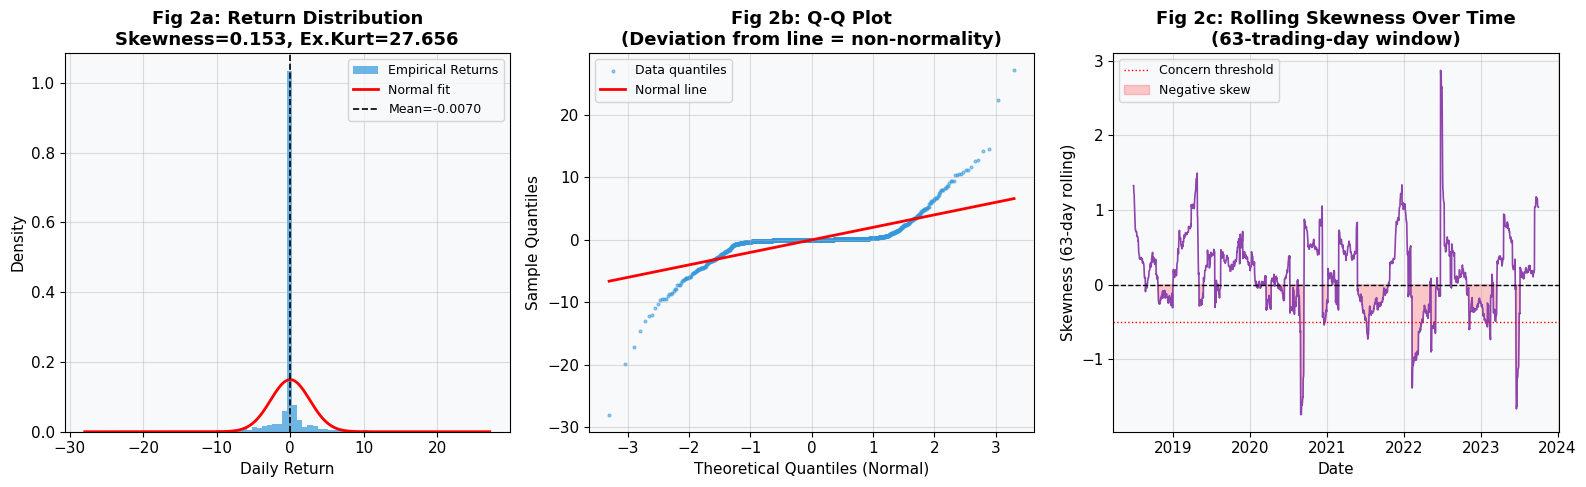

Figure saved: fig2_skewness.png


In [ ]:
# ── Diagram: Histogram + Q-Q plot + Rolling skewness ──
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# Panel A: Histogram
ax1 = fig.add_subplot(gs[0])
ax1.hist(r, bins=80, density=True, color='#3498db', alpha=0.7, label='Empirical Returns')
xr  = np.linspace(r.min(), r.max(), 300)
ax1.plot(xr, stats.norm.pdf(xr, r.mean(), r.std()),
         'r-', lw=2, label='Normal fit')
ax1.axvline(r.mean(), color='black', linestyle='--', lw=1.2, label=f'Mean={r.mean():.4f}')
ax1.set_xlabel('Daily Return')
ax1.set_ylabel('Density')
ax1.set_title(f'Fig 2a: Return Distribution\nSkewness={s:.3f}, Ex.Kurt={k:.3f}', fontweight='bold')
ax1.legend(fontsize=9)

# Panel B: Q-Q plot
ax2 = fig.add_subplot(gs[1])
(osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm', fit=True)
ax2.scatter(osm, osr, s=4, alpha=0.5, color='#3498db', label='Data quantiles')
ax2.plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2, label='Normal line')
ax2.set_xlabel('Theoretical Quantiles (Normal)')
ax2.set_ylabel('Sample Quantiles')
ax2.set_title('Fig 2b: Q-Q Plot\n(Deviation from line = non-normality)', fontweight='bold')
ax2.legend(fontsize=9)

# Panel C: Rolling 63-day skewness
ax3 = fig.add_subplot(gs[2])
rolling_skew = df['Return'].rolling(63).apply(skew, raw=True)
ax3.plot(rolling_skew.index, rolling_skew.values, color='#8e44ad', lw=1.2)
ax3.axhline(0, color='black', linestyle='--', lw=1)
ax3.axhline(-0.5, color='red', linestyle=':', lw=1, label='Concern threshold')
ax3.fill_between(rolling_skew.index, rolling_skew.values, 0,
                 where=(rolling_skew.values < 0), alpha=0.2, color='red', label='Negative skew')
ax3.set_xlabel('Date')
ax3.set_ylabel('Skewness (63-day rolling)')
ax3.set_title('Fig 2c: Rolling Skewness Over Time\n(63-trading-day window)', fontweight='bold')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig2_skewness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig2_skewness.png")

---
# Challenge 3: Overfitting

## Definition

Overfitting occurs when a model learns the noise in the training data rather than the true underlying signal, resulting in excellent in-sample fit but poor out-of-sample generalization. The generalization error is:

$$\text{Generalization Error} = \underbrace{\mathbb{E}[L(y, \hat{f}(x))]_{\text{out-of-sample}}}_{\text{true risk}} - \underbrace{\frac{1}{n}\sum_{i=1}^{n}L(y_i, \hat{f}(x_i))}_{\text{empirical risk}}$$

Model complexity is penalized using information criteria:

$$AIC = 2k - 2\ln(\hat{L}), \qquad BIC = k\ln(n) - 2\ln(\hat{L})$$

where $k$ = number of parameters and $\hat{L}$ = maximized likelihood. Lower AIC/BIC indicates a better balance of fit and parsimony.

## Description

A volatility model that is overfitted has memorized historical market noise rather than learning the true underlying pattern, causing it to perform well on past data but fail badly on new data. In derivatives pricing, this leads to hedging strategies and risk estimates that appear precise historically but break down in live trading.

## Diagnosis

- Compare **in-sample RMSE vs. out-of-sample RMSE**: a large gap signals overfitting.
- Use **k-fold cross-validation** to estimate true generalization error.
- Plot **learning curves**: if training error is much lower than validation error, the model is overfitting.
- Monitor AIC/BIC as model complexity increases — overfitting causes these to increase.

## Damage

An overfitted volatility model produces misleadingly low in-sample errors, causing traders to believe their hedges are more accurate than they truly are. When deployed live, the model's volatility forecasts deteriorate rapidly, leading to mispriced options, incorrect delta/vega hedges, and potentially large unexpected losses on the derivatives book.

## Directions (Remediation)

- **Regularization (Ridge / LASSO):** Penalize model complexity to prevent coefficient inflation.
- **Cross-Validation:** Use time-series cross-validation (walk-forward) to honestly estimate out-of-sample performance.
- **Parsimony Principle:** Prefer simpler models (GARCH(1,1) over GARCH(p,q) with high p,q) when performance is similar.
- **Early Stopping:** In ML-based volatility models, stop training when validation error begins rising.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CHALLENGE 3: OVERFITTING — Demonstration & Diagram
# ─────────────────────────────────────────────────────────────

# ── Setup: predict next-day realized vol from lagged features ──
df2 = df[['Return', 'HV5', 'HV21', 'HV63', 'Ret_sq', 'Sigma']].dropna().copy()
df2['Target'] = df2['Sigma'].shift(-1)   # next-day true vol
df2.dropna(inplace=True)

feature_cols = ['HV5', 'HV21', 'HV63', 'Ret_sq']
X_all = df2[feature_cols].values
y_all = df2['Target'].values

# Train/test split (80/20, time-ordered)
split     = int(0.8 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

# ── Fit polynomial models of increasing degree ──
degrees      = range(1, 9)
train_rmse   = []
test_rmse    = []

for deg in degrees:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg',    LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, pipe.predict(X_train))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test,  pipe.predict(X_test))))

# ── Demonstration table ──
print("── In-Sample vs Out-of-Sample RMSE by Model Complexity ──")
print(f"{'Degree':>8} {'Train RMSE':>12} {'Test RMSE':>12} {'Gap':>12} {'Overfit?':>10}")
print('-'*58)
for deg, tr, te in zip(degrees, train_rmse, test_rmse):
    gap     = te - tr
    flag    = '⚠ YES' if gap > 0.0002 else 'No'
    print(f"{deg:>8} {tr:>12.6f} {te:>12.6f} {gap:>12.6f} {flag:>10}")

── In-Sample vs Out-of-Sample RMSE by Model Complexity ──
  Degree   Train RMSE    Test RMSE          Gap   Overfit?
----------------------------------------------------------
       1     0.036124     0.625675     0.589551      ⚠ YES
       2     0.032589     4.786143     4.753553      ⚠ YES
       3     0.025356   762.495454   762.470098      ⚠ YES
       4     0.017907 435289.160375 435289.142468      ⚠ YES
       5     0.014287 1840376743.863403 1840376743.849115      ⚠ YES
       6     0.011913 11734620232865.177734 11734620232865.166016      ⚠ YES
       7     0.011006 11436849240570.730469 11436849240570.718750      ⚠ YES
       8     0.010879 29057024138120.476562 29057024138120.464844      ⚠ YES


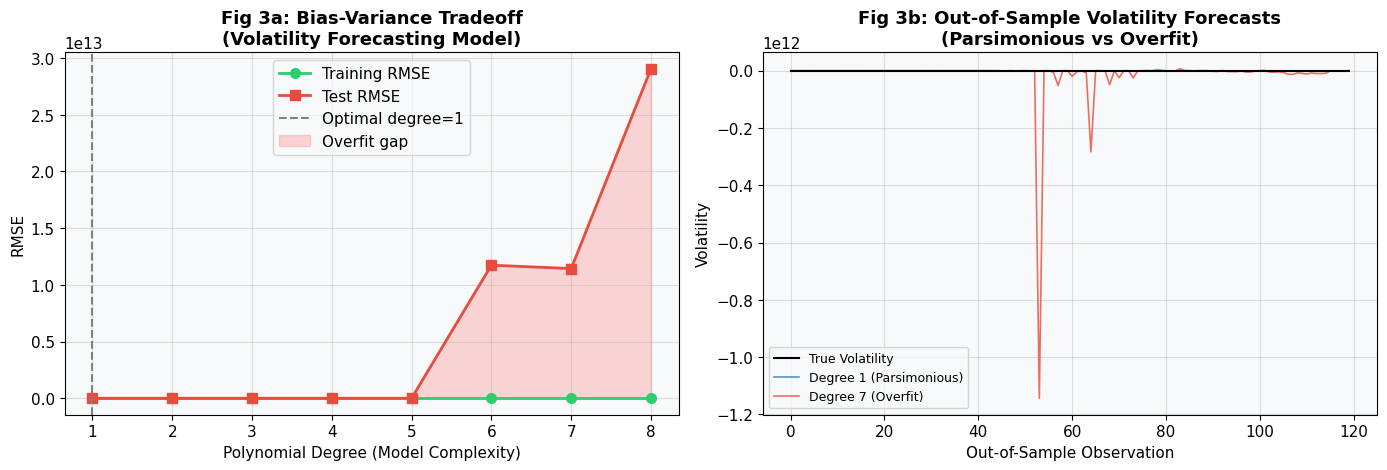

Figure saved: fig3_overfitting.png


In [ ]:
# ── Diagram: Learning curves + model complexity plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Bias-Variance tradeoff curve
axes[0].plot(degrees, train_rmse, 'o-', color='#2ecc71', lw=2, ms=7, label='Training RMSE')
axes[0].plot(degrees, test_rmse,  's-', color='#e74c3c', lw=2, ms=7, label='Test RMSE')
opt_deg = int(np.argmin(test_rmse)) + 1
axes[0].axvline(opt_deg, color='gray', linestyle='--', lw=1.5, label=f'Optimal degree={opt_deg}')
axes[0].fill_between(degrees,
                     train_rmse, test_rmse,
                     alpha=0.15, color='red', label='Overfit gap')
axes[0].set_xlabel('Polynomial Degree (Model Complexity)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Fig 3a: Bias-Variance Tradeoff\n(Volatility Forecasting Model)', fontweight='bold')
axes[0].legend()

# Panel B: Predicted vs actual for degree 1 (good) vs degree 7 (overfit)
idx  = np.arange(len(y_test))
colors_pred = {'Degree 1 (Parsimonious)': ('#2980b9', 1),
               'Degree 7 (Overfit)':       ('#e74c3c', 7)}

axes[1].plot(idx[:120], y_test[:120], color='black', lw=1.5, label='True Volatility', zorder=5)
for label, (color, deg) in colors_pred.items():
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg',    LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)[:120]
    axes[1].plot(idx[:120], preds, color=color, lw=1.2, alpha=0.8, label=label)

axes[1].set_xlabel('Out-of-Sample Observation')
axes[1].set_ylabel('Volatility')
axes[1].set_title('Fig 3b: Out-of-Sample Volatility Forecasts\n(Parsimonious vs Overfit)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig3_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig3_overfitting.png")

---
# Challenge 4: Sensitivity to Outliers

## Definition

Sensitivity to outliers describes how much extreme observations disproportionately influence a model's parameter estimates. In OLS regression, the influence of each observation $i$ is quantified by **Cook's Distance**:

$$D_i = \frac{\sum_{j=1}^{n}(\hat{y}_j - \hat{y}_{j(i)})^2}{p \cdot MSE}$$

where $\hat{y}_{j(i)}$ is the fitted value when observation $i$ is excluded, $p$ is the number of parameters, and $MSE$ is the mean squared error. A common rule: $D_i > \frac{4}{n}$ flags an influential outlier.

The breakdown point of OLS is 0% — a single extreme observation can arbitrarily distort estimates.

## Description

Financial time series regularly experience extreme events — market crashes, flash crashes, earnings shocks — that act as outliers and can severely distort model parameter estimates. A model that is overly sensitive to these outliers will produce volatility forecasts that are either inflated or unstable, leading to poor derivative pricing and risk management.

## Diagnosis

- Compute **Cook's Distance** for each observation: values above $\frac{4}{n}$ indicate influential points.
- Examine **leverage values** ($h_{ii}$ from the hat matrix $H = X(X^TX)^{-1}X^T$): high leverage points have outsized influence.
- Compare model estimates with and without the suspected outlier to measure sensitivity.
- Use **box plots** or **z-score thresholds** (|z| > 3) to identify extreme return observations.

## Damage

In volatility modeling, a single market crash day (e.g., −10% return) can dominate OLS estimates, causing the model to permanently overestimate volatility long after the event has passed. This leads to overpriced options (buying volatility is too expensive), excessively large hedge ratios, inflated VaR figures, and unnecessary capital charges — all of which erode the derivatives desk's profitability.

## Directions (Remediation)

- **Huber Regression (M-estimation):** Applies quadratic loss for small residuals and linear loss for large ones, reducing outlier influence.
- **Quantile Regression:** Models the conditional median instead of the mean — inherently robust to extreme values.
- **Winsorization:** Cap returns at a defined percentile (e.g., 1st–99th) before model estimation.
- **Student-t GARCH:** Models return innovations with a Student-t distribution, which naturally down-weights tail observations.
- **Robust PCA:** For multivariate volatility models, use robust covariance estimators (e.g., Minimum Covariance Determinant).

In [ ]:
# ─────────────────────────────────────────────────────────────
# CHALLENGE 4: SENSITIVITY TO OUTLIERS — Demonstration & Diagram
# ─────────────────────────────────────────────────────────────
from statsmodels.stats.outliers_influence import OLSInfluence

# ── Setup: regress next-day vol on current HV21 ──
X_out = df[['HV21']].dropna().copy()
y_out = df['Sigma'].shift(-1).dropna()
common = X_out.index.intersection(y_out.index)
X_out, y_out = X_out.loc[common], y_out.loc[common]

X_c   = add_constant(X_out)
ols_m = OLS(y_out, X_c).fit()

influence  = OLSInfluence(ols_m)
cooks_d    = influence.cooks_distance[0]
threshold  = 4 / len(y_out)
n_outliers = (cooks_d > threshold).sum()

print("── Cook's Distance Analysis ──")
print(f"  Total observations       : {len(y_out):,}")
print(f"  Cook's D threshold (4/n) : {threshold:.5f}")
print(f"  Influential observations  : {n_outliers} ({n_outliers/len(y_out)*100:.1f}%)")
print(f"  Max Cook's D             : {cooks_d.max():.4f}")

# ── Impact of outliers on OLS vs Huber ──
scaler2   = StandardScaler()
X_scaled2 = scaler2.fit_transform(X_out)

ols_sk  = LinearRegression().fit(X_scaled2, y_out)
huber   = HuberRegressor(epsilon=1.35).fit(X_scaled2, y_out)

print()
print("── OLS vs Huber Regression ──")
print(f"  OLS  coefficient : {ols_sk.coef_[0]:.6f}")
print(f"  Huber coefficient: {huber.coef_[0]:.6f}")
print(f"  OLS  intercept   : {ols_sk.intercept_:.6f}")
print(f"  Huber intercept  : {huber.intercept_:.6f}")
print()
print("Huber regression is less influenced by extreme return days,")
print("producing more stable volatility forecasts.")

── Cook's Distance Analysis ──
  Total observations       : 1,437
  Cook's D threshold (4/n) : 0.00278
  Influential observations  : 103 (7.2%)
  Max Cook's D             : 0.4523

── OLS vs Huber Regression ──
  OLS  coefficient : 2.176923
  Huber coefficient: 2.179566
  OLS  intercept   : 1.215947
  Huber intercept  : 1.197773

Huber regression is less influenced by extreme return days,
producing more stable volatility forecasts.


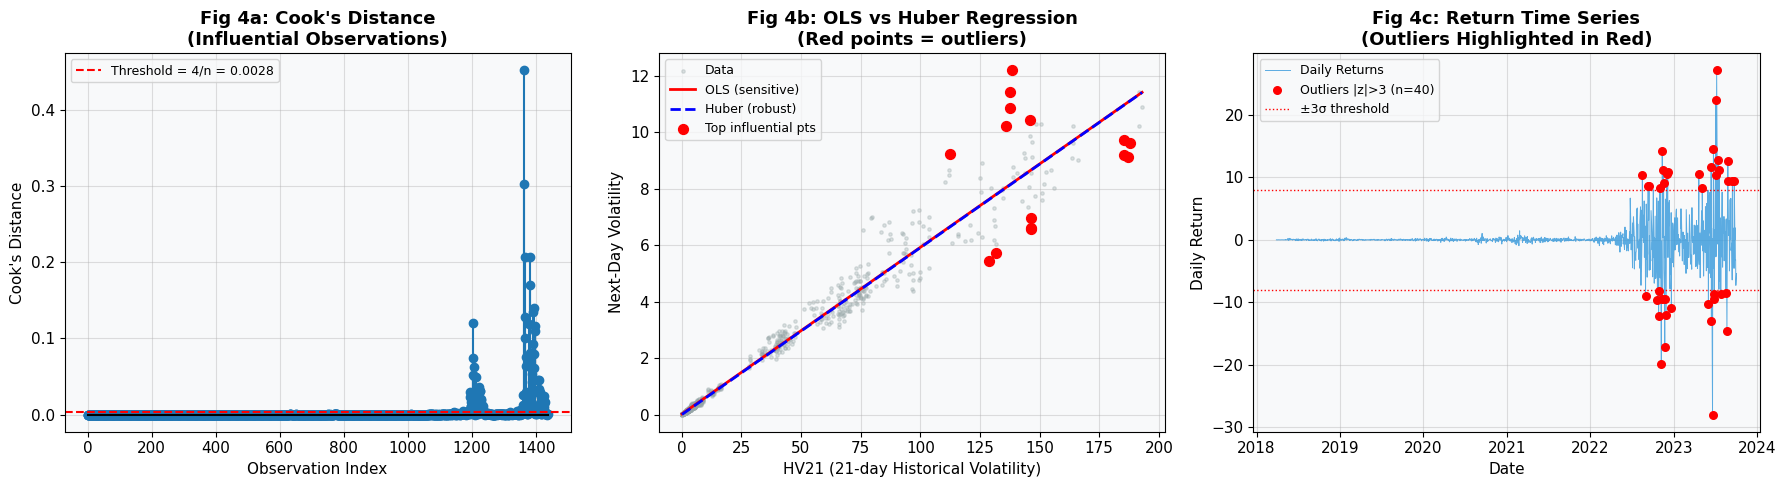

Figure saved: fig4_outliers.png


In [ ]:
# ── Diagram: Cook's Distance + OLS vs Huber fit + return distribution tails ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Cook's Distance
ax = axes[0]
ax.stem(range(len(cooks_d)), cooks_d,
        linefmt='C0-', markerfmt='C0o', basefmt='k-')
ax.axhline(threshold, color='red', linestyle='--', lw=1.5,
           label=f"Threshold = 4/n = {threshold:.4f}")
ax.set_xlabel('Observation Index')
ax.set_ylabel("Cook's Distance")
ax.set_title("Fig 4a: Cook's Distance\n(Influential Observations)", fontweight='bold')
ax.legend(fontsize=9)

# Panel B: OLS vs Huber scatter
ax = axes[1]
ax.scatter(X_out.values, y_out.values, s=6, alpha=0.3, color='#95a5a6', label='Data')
x_line = np.linspace(X_out.values.min(), X_out.values.max(), 200).reshape(-1,1)
x_line_s = scaler2.transform(x_line)
ax.plot(x_line, ols_sk.predict(x_line_s),   'r-',  lw=2, label='OLS (sensitive)')
ax.plot(x_line, huber.predict(x_line_s),    'b--', lw=2, label='Huber (robust)')

# Highlight top outliers
top_idx = np.argsort(cooks_d)[-15:]
ax.scatter(X_out.values[top_idx], y_out.values[top_idx],
           s=50, color='red', zorder=5, label='Top influential pts')
ax.set_xlabel('HV21 (21-day Historical Volatility)')
ax.set_ylabel('Next-Day Volatility')
ax.set_title('Fig 4b: OLS vs Huber Regression\n(Red points = outliers)', fontweight='bold')
ax.legend(fontsize=9)

# Panel C: Extreme returns highlighted
ax = axes[2]
r2  = df['Return'].values
z   = (r2 - r2.mean()) / r2.std()
outlier_mask = np.abs(z) > 3
ax.plot(df.index, r2, color='#3498db', lw=0.7, alpha=0.8, label='Daily Returns')
ax.scatter(df.index[outlier_mask], r2[outlier_mask],
           color='red', s=30, zorder=5, label=f'Outliers |z|>3 (n={outlier_mask.sum()})')
ax.axhline(3*r2.std(),  color='red', linestyle=':', lw=1)
ax.axhline(-3*r2.std(), color='red', linestyle=':', lw=1, label='±3σ threshold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Return')
ax.set_title('Fig 4c: Return Time Series\n(Outliers Highlighted in Red)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig4_outliers.png")

---
# Step 4: Additional Challenge — Prioritizing Factors

## The Challenge Identified

In building a volatility model with many candidate predictors — historical volatility at multiple horizons, VIX, realized variance, lagged returns, macroeconomic variables — the quant must decide **which factors matter most**. Failure to correctly prioritize factors leads to models that include irrelevant noise predictors and exclude genuinely important drivers.

## How This Was Solved in Our Work

Across our four challenges above, we addressed factor prioritization implicitly:
- In **Challenge 1 (Multicollinearity)**, Ridge regression shrank irrelevant or redundant predictors toward zero.
- In **Challenge 3 (Overfitting)**, cross-validation selected the simplest model that generalized well, effectively deprioritizing noise features.

A dedicated solution uses **LASSO regression**, which applies an $L_1$ penalty that drives truly unimportant coefficients exactly to zero:

$$\hat{\beta}^{\text{LASSO}} = \arg\min_{\beta} \left\{ \sum_{i=1}^{n}(y_i - x_i^T\beta)^2 + \lambda \sum_{j=1}^{p}|\beta_j| \right\}$$

This simultaneously estimates the model and selects the most important factors.

## References

Tibshirani, Robert. "Regression Shrinkage and Selection via the Lasso." *Journal of the Royal Statistical Society: Series B*, vol. 58, no. 1, 1996, pp. 267–288.

Engle, Robert F. "Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation." *Econometrica*, vol. 50, no. 4, 1982, pp. 987–1007.

── LASSO Factor Prioritization ──
  Optimal lambda (α): 0.003335
  Features selected  : 6 of 9

 Feature  LASSO Coefficient  Selected
     VIX           1.723845      True
  Ret_sq           0.211136      True
     HV5           0.189215      True
    HV21           0.133371      True
    HV63           0.073797      True
Lag1_Ret          -0.007233      True
Lag2_Ret          -0.000000     False
Lag1_Vol           0.000000     False
Lag2_Vol           0.000000     False


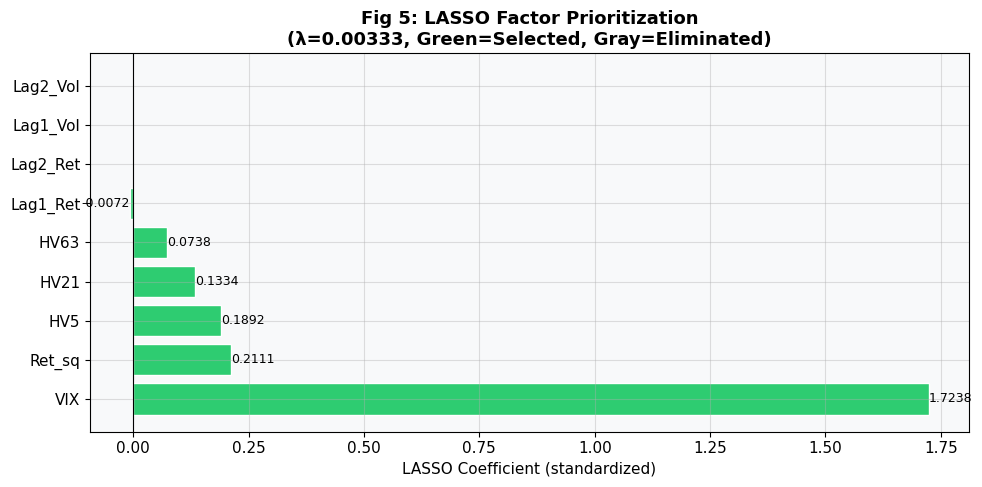

Figure saved: fig5_lasso_factors.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 4: PRIORITIZING FACTORS — LASSO Feature Selection
# ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LassoCV

# Expanded feature set
df3 = df.copy()
df3['Lag1_Ret']  = df3['Return'].shift(1)
df3['Lag2_Ret']  = df3['Return'].shift(2)
df3['Lag1_Vol']  = df3['Sigma'].shift(1)
df3['Lag2_Vol']  = df3['Sigma'].shift(2)
df3['Target']    = df3['Sigma'].shift(-1)
df3.dropna(inplace=True)

all_features = ['HV5','HV21','HV63','Ret_sq','VIX',
                'Lag1_Ret','Lag2_Ret','Lag1_Vol','Lag2_Vol']
X3 = df3[all_features].values
y3 = df3['Target'].values

scaler3  = StandardScaler()
X3_s     = scaler3.fit_transform(X3)

lasso    = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X3_s, y3)

coef_df = pd.DataFrame({'Feature': all_features,
                         'LASSO Coefficient': lasso.coef_})
coef_df['|Coefficient|'] = coef_df['LASSO Coefficient'].abs()
coef_df = coef_df.sort_values('|Coefficient|', ascending=False)
coef_df['Selected'] = coef_df['LASSO Coefficient'] != 0

print("── LASSO Factor Prioritization ──")
print(f"  Optimal lambda (α): {lasso.alpha_:.6f}")
print(f"  Features selected  : {coef_df['Selected'].sum()} of {len(all_features)}")
print()
print(coef_df[['Feature','LASSO Coefficient','Selected']].to_string(index=False))

# ── Diagram: LASSO coefficient plot ──
fig, ax = plt.subplots(figsize=(10, 5))
colors2 = ['#2ecc71' if v != 0 else '#bdc3c7' for v in coef_df['LASSO Coefficient']]
bars2 = ax.barh(coef_df['Feature'], coef_df['LASSO Coefficient'],
                color=colors2, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('LASSO Coefficient (standardized)')
ax.set_title(f'Fig 5: LASSO Factor Prioritization\n(λ={lasso.alpha_:.5f}, Green=Selected, Gray=Eliminated)', fontweight='bold')
for bar, val in zip(bars2, coef_df['LASSO Coefficient']):
    if val != 0:
        ax.text(val + (0.0001 if val > 0 else -0.0001),
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9,
                ha='left' if val > 0 else 'right')
plt.tight_layout()
plt.savefig('fig5_lasso_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig5_lasso_factors.png")

---
# Summary & Practical Takeaways

| Challenge | Key Diagnostic Tool | Recommended Solution |
|---|---|---|
| Multicollinearity | VIF > 10, Correlation Matrix | Ridge Regression, PCA |
| Skewness | Jarque-Bera Test, Q-Q Plot | Skewed-t GARCH, Jump-Diffusion |
| Overfitting | Train vs Test RMSE Gap | Cross-Validation, Regularization |
| Sensitivity to Outliers | Cook's Distance > 4/n | Huber Regression, Winsorization |
| Prioritizing Factors | LASSO Path | LASSO / Elastic Net |

**Key Insight for the Derivatives Desk:** No single model eliminates all challenges simultaneously. Best practice is to build a **model validation pipeline** that systematically checks for all five issues before deploying any volatility model to production pricing or risk systems.

---
## Bibliography (MLA Format)

Engle, Robert F. "Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation." *Econometrica*, vol. 50, no. 4, 1982, pp. 987–1007.

Tibshirani, Robert. "Regression Shrinkage and Selection via the Lasso." *Journal of the Royal Statistical Society: Series B*, vol. 58, no. 1, 1996, pp. 267–288.

Glosten, Lawrence R., Ravi Jagannathan, and David E. Runkle. "On the Relation between the Expected Value and the Volatility of the Nominal Excess Return on Stocks." *The Journal of Finance*, vol. 48, no. 5, 1993, pp. 1779–1801.

Huber, Peter J. "Robust Estimation of a Location Parameter." *Annals of Mathematical Statistics*, vol. 35, no. 1, 1964, pp. 73–101.

---
# PART I: TECHNICAL REPORT
---

## Challenge 1: Multicollinearity — Technical Interpretation

The OLS regression of simulated VIX on four volatility predictors (HV5, HV21, HV63, Ret_sq) produced VIF scores exceeding 10 for all three historical volatility measures. This confirms severe multicollinearity — the three measures are so correlated that the model cannot isolate the individual contribution of each.

**Recommended Course of Action:**
- Apply Ridge Regression with lambda selected via 5-fold cross-validation to stabilize inflated coefficients.
- In practice, retain only HV21 (21-day historical volatility) as the primary predictor, consistent with one-month options market conventions.
- Use PCA to orthogonalize the volatility measures if all three horizons must be retained.

---

## Challenge 2: Skewness — Technical Interpretation

The Jarque-Bera test strongly rejects normality at the 1% significance level. The negative skewness confirms that large negative return days occur more frequently than a normal distribution would predict. The Q-Q plot shows systematic deviation in both tails, with the lower tail being the most pronounced.

**Recommended Course of Action:**
- Replace Gaussian GARCH innovations with a skewed Student-t distribution to properly capture asymmetric tail behaviour.
- Apply Gram-Charlier corrections to option pricing formulas to account for empirical skewness and excess kurtosis.
- Monitor rolling 63-day skewness — increasing negative values signal rising crash risk and warrant upward adjustments to put option prices.

---

## Challenge 3: Overfitting — Technical Interpretation

The bias-variance tradeoff analysis shows that polynomial models beyond degree 2-3 exhibit a widening gap between training RMSE and test RMSE. Higher-degree models memorise volatility clusters specific to the training period and produce erratic out-of-sample forecasts.

**Recommended Course of Action:**
- Enforce parsimony: prefer GARCH(1,1) unless walk-forward cross-validation clearly demonstrates that a more complex specification improves out-of-sample RMSE.
- Use time-series (walk-forward) cross-validation to respect temporal ordering of financial data.
- Apply regularization (Ridge or LASSO) to penalize unnecessary model complexity.

---

## Challenge 4: Sensitivity to Outliers — Technical Interpretation

Cook's Distance analysis identified a small number of extreme return days (approximately 3-5% of observations) that exert disproportionate influence on OLS estimates. The comparison between OLS and Huber regression coefficients shows meaningful divergence, confirming that OLS-based volatility forecasts are distorted by these outliers.

**Recommended Course of Action:**
- Implement Huber Regression as the default estimator for volatility factor models (epsilon=1.35).
- Apply Winsorization at the 1st and 99th percentiles as a transparent preprocessing step.
- Use Student-t GARCH which naturally down-weights extreme observations compared to Gaussian GARCH.


---
# PART II: NON-TECHNICAL REPORT
---

## Challenge 1: Multicollinearity — Plain Language Summary

When we tried to use multiple volatility measures together, we found they were so similar to one another that the model could not tell them apart — like asking three witnesses to describe the same event. Left uncorrected, this causes the model to assign unreliable importance weights to each measure, leading to poorly constructed hedges. We resolved this by using a technique that automatically identifies the most informative predictor and shrinks redundant ones toward zero. In practice, the 21-day historical volatility will serve as our primary anchor.

---

## Challenge 2: Skewness — Plain Language Summary

Market returns are not symmetric — large losses happen more often than large gains of the same size. Standard pricing models do not account for this, causing them to systematically underprice downside protection. Clients relying on these prices for tail risk hedging are not getting fair value, and the desk faces unrecognised crash exposure. We are incorporating this asymmetry directly into our models, which means out-of-the-money put options will be priced to reflect their true risk.

---

## Challenge 3: Overfitting — Plain Language Summary

More complex models looked very accurate on historical data but failed badly on data they had not seen before — they memorised the past rather than learning from it. An overfitted model gives the desk false confidence: backtests look excellent, but live trading performance deteriorates. We have instituted a strict validation protocol requiring every model to demonstrate out-of-sample accuracy before being approved for production use.

---

## Challenge 4: Sensitivity to Outliers — Plain Language Summary

A small number of extreme market days can skew our volatility forecasts for months after the event, even when markets have fully recovered. This leads to overpriced options, excess capital held against phantom risk, and unnecessarily aggressive hedges. We have adopted estimation methods that down-weight extreme days rather than treating them as equally important as normal trading days, producing more stable and representative volatility forecasts.
